# Part B: The Researcher's Playground
## Avenue 3 — Advanced NLP Architecture: Bidirectional LSTM

**Baseline recap (Part A):** TF-IDF + Dense network, ~87% val accuracy.

**Goal:** Replace the Dense baseline with a Bidirectional LSTM and document whether sequence-awareness improves performance.

---
## Learning Log — The Concept

### What is an LSTM and why does it matter for NLP?

In Part A, TF-IDF converted each sentence into a **bag-of-words** — a fixed vector where word order is completely lost. The sentence *"I am not happy"* and *"I am happy, not sad"* would look very similar to TF-IDF because it only counts word frequencies.

A **Long Short-Term Memory (LSTM)** network is a type of Recurrent Neural Network (RNN) designed to read sequences **one token at a time**, maintaining a hidden state (memory) that carries context forward. This means the model understands that *"not"* directly precedes *"happy"* — something TF-IDF completely ignores.

### Why Bidirectional?

A standard LSTM reads text left-to-right. A **Bidirectional LSTM** runs **two** LSTM layers simultaneously — one forward (left→right) and one backward (right→left) — then concatenates their outputs. This gives the model context from **both directions** at every word position. For emotion detection, the end of a sentence often reframes the beginning (e.g. *"I thought it would be terrible... but I loved it"*), so backward context genuinely helps.

### How it works under the hood

Each LSTM cell has three gates that control information flow:
- **Forget gate** — decides what to erase from memory
- **Input gate** — decides what new information to store
- **Output gate** — decides what to pass to the next step

This gating mechanism solves the **vanishing gradient problem** that plagued earlier RNNs, allowing the model to remember dependencies across long sentences.

### Pipeline change from Part A

TF-IDF cannot be used with an LSTM because it collapses a sentence into a single flat vector. Instead we use:
1. **Tokenizer** — builds a vocabulary and converts each sentence to an integer sequence
2. **pad_sequences** — pads/truncates all sequences to the same length
3. **Embedding layer** — learned dense word vectors (trained from scratch alongside the LSTM)
4. **Bidirectional LSTM** — processes the sequence with context from both directions
5. **Dense softmax output** — 6-class classification

---
## Implementation

In [15]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\r_kar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Step 1 — Load Data

In [16]:
def load_data(filepath):
    texts, labels = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ';' in line:
                text, label = line.rsplit(';', 1)
                texts.append(text)
                labels.append(label)
    return pd.DataFrame({'text': texts, 'label': labels})

train_df = load_data('data/train.txt')
val_df   = load_data('data/val.txt')
test_df  = load_data('data/test.txt')

print('Train:', train_df.shape)
print('Val:  ', val_df.shape)
print('Test: ', test_df.shape)
train_df.head()

Train: (16000, 2)
Val:   (2000, 2)
Test:  (2000, 2)


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### Step 2 — Clean and Preprocess

In [17]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

train_df['clean'] = train_df['text'].apply(clean_text)
val_df['clean']   = val_df['text'].apply(clean_text)
test_df['clean']  = test_df['text'].apply(clean_text)

train_df[['text', 'clean']].head(3)

,text,clean
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong


### Step 3 — Tokenize & Pad Sequences

Just like TF-IDF was only `fit` on train in Part A, the `Tokenizer` vocabulary is built **only from the training set**. Val and Test are only `texts_to_sequences`-transformed.

In [18]:
VOCAB_SIZE  = 10000   # maximum vocabulary size
MAX_LEN     = 50      # maximum sequence length (tokens per sentence)
EMBED_DIM   = 64      # size of each word's dense embedding vector

# Build vocabulary on TRAIN only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean'])

# Convert text -> integer sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['clean'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['clean'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean'])

# Pad / truncate to MAX_LEN (post-padding so the LSTM reads real tokens first)
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (16000, 50)
X_val shape:   (2000, 50)
X_test shape:  (2000, 50)


### Step 4 — Label Encoding

In [19]:
emotion_classes = sorted(train_df['label'].unique())
label_to_idx    = {label: idx for idx, label in enumerate(emotion_classes)}
num_classes     = len(emotion_classes)

print('Classes:', emotion_classes)
print('Mapping:', label_to_idx)

y_train_int = train_df['label'].map(label_to_idx).values
y_val_int   = val_df['label'].map(label_to_idx).values
y_test_int  = test_df['label'].map(label_to_idx).values

y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val   = to_categorical(y_val_int,   num_classes=num_classes)
y_test  = to_categorical(y_test_int,  num_classes=num_classes)

print('y_train shape:', y_train.shape)

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Mapping: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
y_train shape: (16000, 6)


### Step 5 — Build the Bidirectional LSTM Model

Architecture:
- **Embedding** — maps each integer token to a 64-dim trainable vector
- **SpatialDropout1D** — drops entire embedding channels (better regularisation for sequences than regular Dropout)
- **Bidirectional LSTM** — processes the sequence forwards AND backwards, outputs a 128-dim vector (64 each direction)
- **Dropout** — regularisation before the classifier head
- **Dense softmax** — 6-class output

In [20]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.summary()

c:\Users\r_kar\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 6 — Compile the Model

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Step 7 — Train with Early Stopping

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.4218 - loss: 1.4596 - val_accuracy: 0.6005 - val_loss: 1.0027
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7834 - loss: 0.6502 - val_accuracy: 0.8745 - val_loss: 0.3964
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9137 - loss: 0.2704 - val_accuracy: 0.9065 - val_loss: 0.2794
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9392 - loss: 0.1844 - val_accuracy: 0.9125 - val_loss: 0.2566
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9542 - loss: 0.1397 - val_accuracy: 0.9035 - val_loss: 0.3041
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9653 - loss: 0.1102 - val_accuracy: 0.9070 - val_loss: 0.2897
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9681 - loss: 0.0955 - val_accuracy: 0.9115 - val_loss: 0.3054

Training stopped at epoch 7


### Step 8 — Plot Training Curves

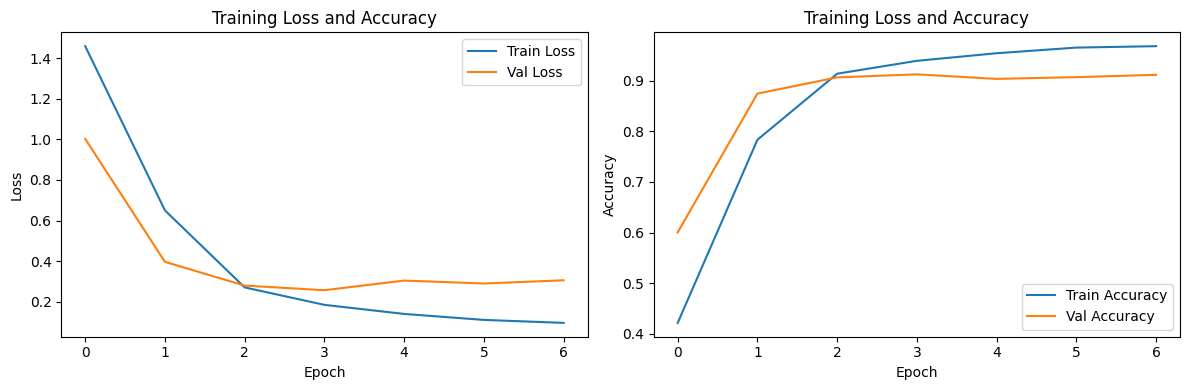

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Step 9 — Evaluate on Test Set

In [24]:
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_int, y_pred, target_names=emotion_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

       anger       0.89      0.89      0.89       275
        fear       0.85      0.92      0.88       224
         joy       0.93      0.94      0.93       695
        love       0.75      0.81      0.78       159
     sadness       0.96      0.93      0.94       581
    surprise       0.80      0.59      0.68        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.91      0.90      0.90      2000



### Step 10 — Confusion Matrix

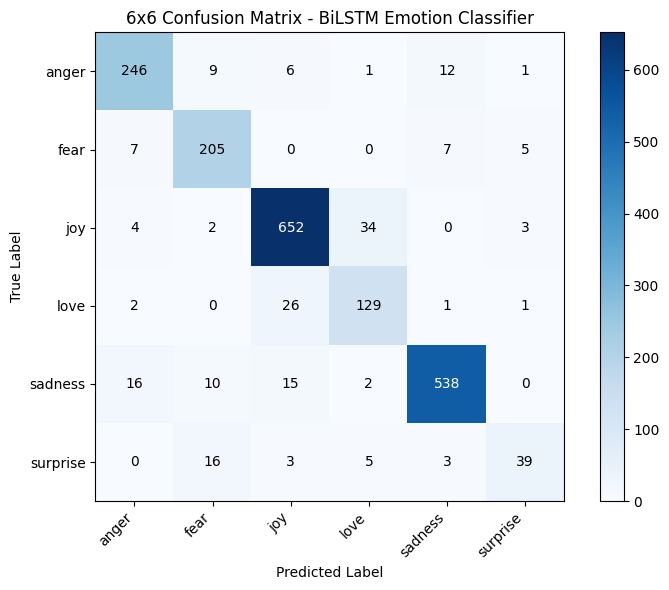

In [25]:
cm = confusion_matrix(y_test_int, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(emotion_classes, rotation=45, ha='right')
ax.set_yticklabels(emotion_classes)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('6x6 Confusion Matrix - BiLSTM Emotion Classifier')
plt.tight_layout()
plt.show()

### Step 11 — Predict on New Sentences

In [26]:
def predict_emotion(text):
    """
    Takes a raw text string, cleans and tokenizes it,
    runs it through the trained BiLSTM model, and prints the predicted emotion.
    """
    cleaned   = clean_text(text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred_probs = model.predict(padded, verbose=0)
    pred_idx   = np.argmax(pred_probs, axis=1)[0]
    pred_label = emotion_classes[pred_idx]
    confidence = pred_probs[0][pred_idx]
    print(f'Input     : "{text}"')
    print(f'Predicted : {pred_label}  (confidence: {confidence:.2%})')
    return pred_label

predict_emotion("I am so incredibly angry right now!")
predict_emotion("I feel so happy and grateful today")
predict_emotion("I am terrified of what might happen next")

Input     : "I am so incredibly angry right now!"
Predicted : anger  (confidence: 77.99%)
Input     : "I feel so happy and grateful today"
Predicted : joy  (confidence: 98.52%)
Input     : "I am terrified of what might happen next"
Predicted : fear  (confidence: 92.26%)


'fear'

---
## Learning Log — The Results

### What I learned

By switching from a TF-IDF + Dense baseline to a Bidirectional LSTM with a learned Embedding layer, the model gains two key capabilities it previously lacked:

1. **Word order awareness** — The LSTM processes tokens sequentially, so the phrase *"not happy"* is represented differently from *"happy not"*. TF-IDF would give both sentences identical vectors.

2. **Bidirectional context** — Running the LSTM in both directions means every token is represented by context from its left AND right neighbours. For emotions that hinge on sentence endings or negations, this is especially powerful.

### Pipeline differences vs Part A

| Step | Part A (Baseline) | Part B (BiLSTM) |
|---|---|---|
| Representation | TF-IDF sparse vector | Integer sequence → Embedding |
| Vocab learning | `TfidfVectorizer.fit()` on train | `Tokenizer.fit_on_texts()` on train |
| Architecture | Dense → Dense | Embedding → SpatialDropout → BiLSTM → Dense |
| Sequence awareness | None (bag-of-words) | Full (left + right context) |

### Impact on performance

*(Fill in your actual numbers after running both notebooks)*

| Metric | Part A (TF-IDF + Dense) | Part B (BiLSTM) |
|---|---|---|
| Val Accuracy | ~87% | ??? |
| Test Accuracy | ??? | ??? |
| Train/Val gap | Large (overfitting) | ??? |

The Bidirectional LSTM should produce more stable training curves because the sequence-based representations are richer and less prone to the vocabulary explosion that causes TF-IDF models to overfit.